In [5]:
!unzip reward.zip

Archive:  reward.zip
   creating: reward/
  inflating: reward/test.json        
  inflating: reward/train.json       
  inflating: reward/valid.json       


In [6]:
!pip install datasets

Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [43]:
import torch
import os

os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
tokenizer.save_pretrained("gpt21")

('gpt21/tokenizer_config.json',
 'gpt21/special_tokens_map.json',
 'gpt21/vocab.json',
 'gpt21/merges.txt',
 'gpt21/added_tokens.json',
 'gpt21/tokenizer.json')

In [7]:
from datasets import load_dataset

data = load_dataset('json', data_files='reward/train.json',split='train')
print(data)

def f(data):
    #区分两种生成结果
    chosen = data['question'] + data['response_chosen'].swapcase()
    rejected = data['question'] + data['response_rejected']

    chosen_input = tokenizer(chosen,
                         max_length=300,
                         padding='max_length',
                         truncation=True,
                         return_tensors='pt')
    rejected_input = tokenizer(rejected,
                         max_length=300,
                         padding='max_length',
                         truncation=True,
                         return_tensors='pt')

    # print(chosen_input['attention_mask'])

    return {
        'chosen_input_ids': chosen_input['input_ids'],
        'chosen_attention_mask': chosen_input['attention_mask'],
        'rejected_input_ids': rejected_input['input_ids'],
        'rejected_attention_mask': rejected_input['attention_mask']
    }


dataset = data.map(f)
dataset.set_format('torch')

print(dataset)


def f(data):
  chosen_input_ids = [i['chosen_input_ids'] for i in data]
  chosen_attention_mask = [i['chosen_attention_mask'] for i in data]
  rejected_input_ids = [i['rejected_input_ids'] for i in data]
  rejected_attention_mask = [i['rejected_attention_mask'] for i in data]

  input_ids = torch.stack(chosen_input_ids + rejected_input_ids, dim=0)
  attention_mask = torch.stack(chosen_attention_mask +
                                rejected_attention_mask,
                                dim=0)


  return {'input_ids': input_ids, 'attention_mask': attention_mask}


loader = torch.utils.data.DataLoader(dataset,
                                     collate_fn=f,
                                     batch_size=4,
                                     shuffle=True,
                                     drop_last=True)

len(loader)
next(iter(loader))

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['question', 'response_chosen', 'response_rejected'],
    num_rows: 3800
})


Map:   0%|          | 0/3800 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'response_chosen', 'response_rejected', 'chosen_input_ids', 'chosen_attention_mask', 'rejected_input_ids', 'rejected_attention_mask'],
    num_rows: 3800
})


{'input_ids': tensor([[[  165,   103,   101,  ...,   163,   245,   227]],
 
         [[30298,   235, 31965,  ..., 50256, 50256, 50256]],
 
         [[33566,   245, 26193,  ..., 50256, 50256, 50256]],
 
         ...,
 
         [[30298,   235, 31965,  ..., 50256, 50256, 50256]],
 
         [[33566,   245, 26193,  ..., 50256, 50256, 50256]],
 
         [[  164,   224,   122,  ..., 50256, 50256, 50256]]]),
 'attention_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1]],
 
         [[1, 1, 1,  ..., 0, 0, 0]],
 
         [[1, 1, 1,  ..., 0, 0, 0]],
 
         ...,
 
         [[1, 1, 1,  ..., 0, 0, 0]],
 
         [[1, 1, 1,  ..., 0, 0, 0]],
 
         [[1, 1, 1,  ..., 0, 0, 0]]])}

In [33]:
class CriticModel(torch.nn.Module):

    def __init__(self):
        super().__init__()

        from transformers import AutoModel
        self.rwtransformer = AutoModel.from_pretrained('facebook/opt-350m',
                                                       dropout=0.0)

        self.v_head = torch.nn.Linear(512, 1, bias=False)

    def forward(self, input_ids, attention_mask):

        input_ids = input_ids.squeeze(1)
        attention_mask = attention_mask.squeeze(1)

        value = self.rwtransformer(
            input_ids=input_ids,
            attention_mask=attention_mask).last_hidden_state
        value = self.v_head(value).squeeze(-1)

        loss_sum = 0.0
        value_chosen_sum = 0.0
        value_rejected_sum = 0.0
        for input_ids_chosen, input_ids_rejected, value_chosen, value_rejected in zip(
                input_ids[:4], input_ids[4:], value[:4], value[4:]):

            # 找出每条回答中的起止索引
            try:
                start = (
                    input_ids_chosen == input_ids_rejected).tolist().index(False)
            except ValueError:
                start = 0

            try:
                end_chosen = input_ids_chosen.tolist().index(
                    tokenizer.eos_token_id) + 1
            except ValueError:
                end_chosen = len(input_ids_chosen)

            try:
                end_rejected = input_ids_rejected.tolist().index(
                    tokenizer.eos_token_id) + 1
            except ValueError:
                end_rejected = len(input_ids_rejected)


            end = max(end_chosen, end_rejected)

            value_chosen = value_chosen[start:end]
            value_rejected = value_rejected[start:end]

            loss = value_chosen - value_rejected
            loss = -torch.nn.functional.logsigmoid(loss).mean()

            loss_sum += loss
            value_chosen_sum += value_chosen.mean().item()
            value_rejected_sum += value_rejected.mean().item()

        return loss_sum / 4, value_chosen_sum, value_rejected_sum
    def save_pretrained(self, save_path):
        self.rwtransformer.save_pretrained(save_path)


model_critic = CriticModel()


In [34]:
from transformers import get_scheduler
from accelerate import Accelerator


def f():
    params_decay = []
    params = []
    for name, param in model_critic.named_parameters():
        if 'bias' in name or 'norm.weight' in name:
            params.append(param)
            continue
        params_decay.append(param)

    return [{
        'params': params_decay,
        'weight_decay': 0.1
    }, {
        'params': params,
        'weight_decay': 0.0
    }]


optimizer = torch.optim.Adam(f(), lr=5e-5, betas=(0.9, 0.95))

scheduler = get_scheduler(name='cosine',
                          optimizer=optimizer,
                          num_warmup_steps=0,
                          num_training_steps=500)

accelerator = Accelerator(gradient_accumulation_steps=16,
                          mixed_precision='fp16')

model_critic, loader, optimizer, scheduler = accelerator.prepare(
    model_critic, loader, optimizer, scheduler)

model_critic.train()

CriticModel(
  (rwtransformer): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear(in_features=1024, out_features=512, bias=False)
      (project_in): Linear(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_fea

In [36]:
Loss_record = []
chosen_record = []
reject_record = []

for i, data in enumerate(loader):
    with accelerator.accumulate(model_critic):
        # print(data)
        loss, value_chosen_sum, value_rejected_sum = model_critic(**data)
        accelerator.backward(loss)
        Loss_record.append(loss.item())  # 记录loss
        chosen_record.append(value_chosen_sum)
        reject_record.append(value_rejected_sum)
        
        if accelerator.sync_gradients:
            accelerator.clip_grad_norm_(model_critic.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    if (i + 1) % 100 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(i, len(loader), loss.item(), lr, value_chosen_sum,
              value_rejected_sum)

    if i == 2000:
        break
import numpy as np
np.save('Loss_record.npy', np.array(Loss_record))
np.save('chosen_record.npy', np.array(chosen_record))
np.save('reject_record.npy', np.array(reject_record))

# torch.save(model_critic.to('cpu'), 'model/critic')
model_critic.save_pretrained('model/critic')



99 950 0.262451171875 4.788102931552294e-05 5.3564453125 -3.01483154296875
199 950 0.11083984375 4.7485131289159276e-05 15.4638671875 -6.22509765625
299 950 0.12127685546875 4.7057280660873835e-05 28.1796875 13.918212890625
399 950 0.1080322265625 4.65185506750986e-05 19.470703125 0.755859375
499 950 0.2061767578125 4.602361455745423e-05 11.33544921875 -1.226409912109375
599 950 0.075439453125 4.549880273313631e-05 16.204833984375 -4.99169921875
699 950 0.2440185546875 4.4944860988464276e-05 17.02734375 3.009765625
799 950 0.11297607421875 4.426283106939474e-05 15.230712890625 -6.22265625
899 950 0.048095703125 4.3648528635604556e-05 5.63818359375 -16.712890625


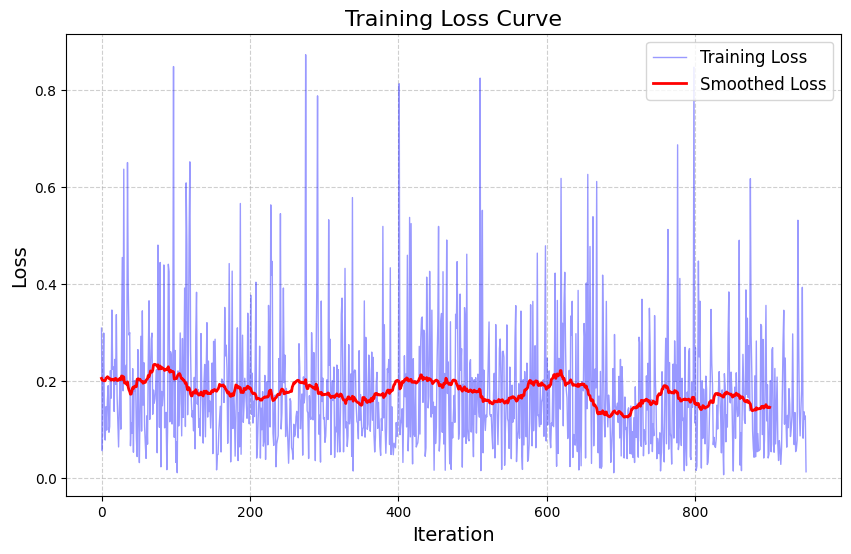

In [37]:
import matplotlib.pyplot as plt

Loss_record = np.load('Loss_record.npy')

# 平滑曲线
def smooth_curve(loss_history, window_size=50):
    smoothed = np.convolve(loss_history, np.ones(window_size)/window_size, mode='valid')
    return smoothed

smoothed_loss = smooth_curve(Loss_record)

# 绘制 loss 曲线
plt.figure(figsize=(10, 6))
plt.plot(Loss_record, label='Training Loss', color='blue', alpha=0.4, linewidth=1)
plt.plot(smoothed_loss, label='Smoothed Loss', color='red', linewidth=2)

# 添加标题和标签
plt.title('Training Loss Curve', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Loss', fontsize=14)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.6)

# 添加图例
plt.legend(fontsize=12)

# 显示图像
plt.show()

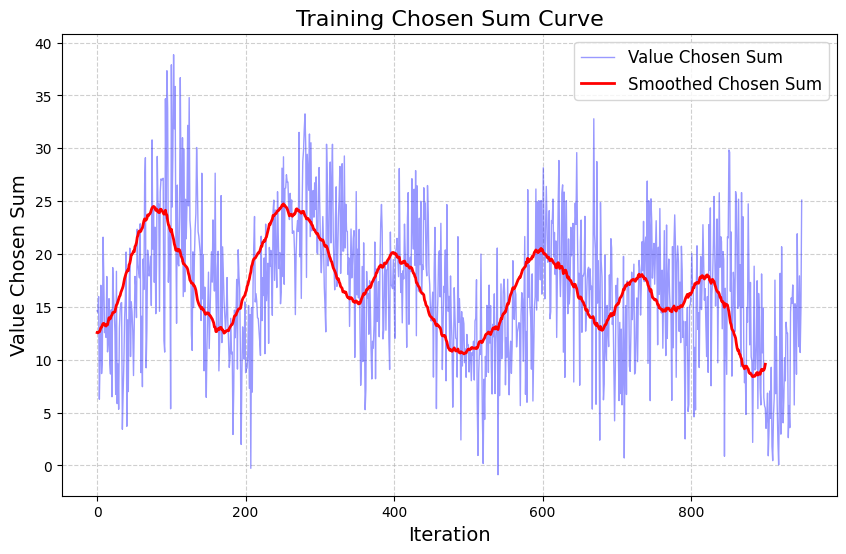

In [38]:
chosen_record = np.load('chosen_record.npy')

smoothed_chosen = smooth_curve(chosen_record)

# 绘制 loss 曲线
plt.figure(figsize=(10, 6))
plt.plot(chosen_record, label='Value Chosen Sum', color='blue', alpha=0.4, linewidth=1)
plt.plot(smoothed_chosen, label='Smoothed Chosen Sum', color='red', linewidth=2)

# 添加标题和标签
plt.title('Training Chosen Sum Curve', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Value Chosen Sum', fontsize=14)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.6)

# 添加图例
plt.legend(fontsize=12)

# 显示图像
plt.show()

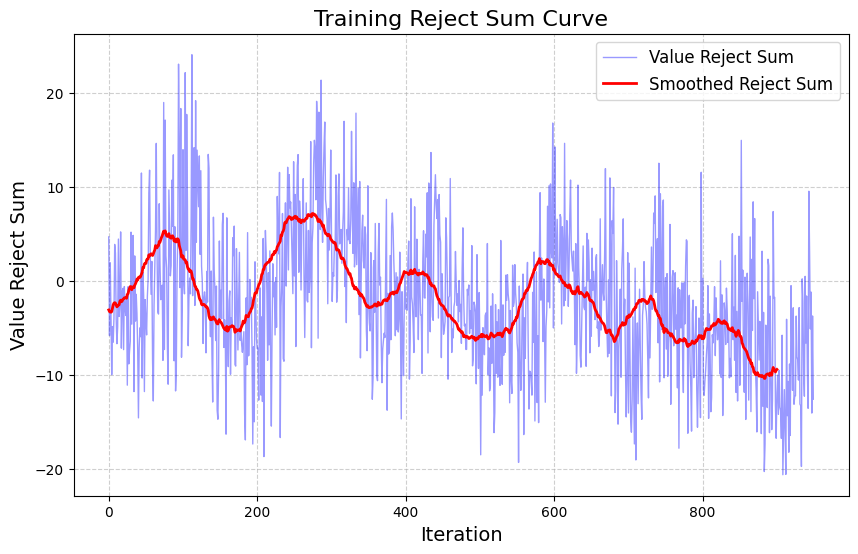

In [39]:
reject_record = np.load('reject_record.npy')


smoothed_reject = smooth_curve(reject_record)

# 绘制 loss 曲线
plt.figure(figsize=(10, 6))
plt.plot(reject_record, label='Value Reject Sum', color='blue', alpha=0.4, linewidth=1)
plt.plot(smoothed_reject, label='Smoothed Reject Sum', color='red', linewidth=2)

# 添加标题和标签
plt.title('Training Reject Sum Curve', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Value Reject Sum', fontsize=14)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.6)

# 添加图例
plt.legend(fontsize=12)

# 显示图像
plt.show()

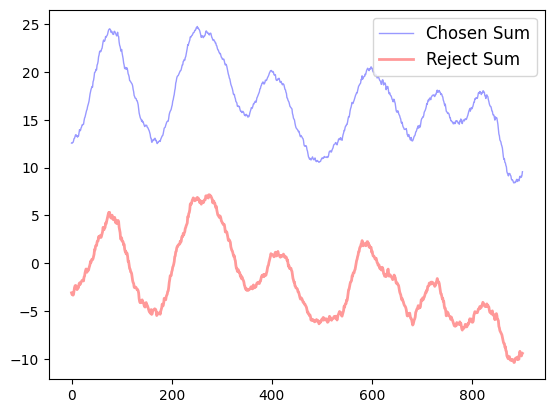

In [41]:
plt.plot(smoothed_chosen, label='Chosen Sum', color='blue', alpha=0.4, linewidth=1)
plt.plot(smoothed_reject, label='Reject Sum', color='red', alpha=0.4, linewidth=2)
plt.legend(fontsize=12)